In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Örnek veri
data = {
    "text": [
        "Manchester United won the match 2-1 after a thrilling game.",
        "The new smartphone model includes AI-based camera features.",
        "The president addressed the nation regarding the new policy.",
        "Regular exercise helps reduce the risk of heart diseases.",
        "The movie received positive reviews from critics and audiences.",
        "Serena Williams announced her retirement from tennis.",
        "Apple is planning to launch its VR headset next year.",
        "Government officials discussed the climate change agreement.",
        "A balanced diet and sleep are essential for good health.",
        "The upcoming film features several Oscar-winning actors.",
        "The team celebrated their championship victory with fans.",
        "Researchers developed a new algorithm for speech recognition.",
        "Parliament passed a new law to support small businesses.",
        "Doctors recommend regular check-ups for early diagnosis.",
        "The actor signed a contract for three upcoming movies."
    ],
    "label": [
        "Sports",
        "Technology",
        "Politics",
        "Health",
        "Entertainment",
        "Sports",
        "Technology",
        "Politics",
        "Health",
        "Entertainment",
        "Sports",
        "Technology",
        "Politics",
        "Health",
        "Entertainment"
    ]
}

# DataFrame oluştur
df = pd.DataFrame(data)
df

,text,label
0,Manchester United won the match 2-1 after a th...,Sports
1,The new smartphone model includes AI-based cam...,Technology
2,The president addressed the nation regarding t...,Politics
3,Regular exercise helps reduce the risk of hear...,Health
4,The movie received positive reviews from criti...,Entertainment
5,Serena Williams announced her retirement from ...,Sports
6,Apple is planning to launch its VR headset nex...,Technology
7,Government officials discussed the climate cha...,Politics
8,A balanced diet and sleep are essential for go...,Health
9,The upcoming film features several Oscar-winni...,Entertainment


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

import re
from collections import Counter

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df.head()

,text,label
0,Manchester United won the match 2-1 after a th...,Sports
1,The new smartphone model includes AI-based cam...,Technology
2,The president addressed the nation regarding t...,Politics
3,Regular exercise helps reduce the risk of hear...,Health
4,The movie received positive reviews from criti...,Entertainment


In [ ]:
df.tail()

,text,label
10,The team celebrated their championship victory...,Sports
11,Researchers developed a new algorithm for spee...,Technology
12,Parliament passed a new law to support small b...,Politics
13,Doctors recommend regular check-ups for early ...,Health
14,The actor signed a contract for three upcoming...,Entertainment


In [ ]:
df.shape #(15,2)

(15, 2)

In [ ]:
df["label"].value_counts()

,count
label,
Sports,3
Technology,3
Politics,3
Health,3
Entertainment,3


In [ ]:
metin = df["text"].iloc[::]
label = df["label"].iloc[::]


In [ ]:
not_clean_text = " ".join(metin.astype(str))
not_clean_text

'Manchester United won the match 2-1 after a thrilling game. The new smartphone model includes AI-based camera features. The president addressed the nation regarding the new policy. Regular exercise helps reduce the risk of heart diseases. The movie received positive reviews from critics and audiences. Serena Williams announced her retirement from tennis. Apple is planning to launch its VR headset next year. Government officials discussed the climate change agreement. A balanced diet and sleep are essential for good health. The upcoming film features several Oscar-winning actors. The team celebrated their championship victory with fans. Researchers developed a new algorithm for speech recognition. Parliament passed a new law to support small businesses. Doctors recommend regular check-ups for early diagnosis. The actor signed a contract for three upcoming movies.'

#Metin ön işleme

In [ ]:
def metin_on_isleme(text):
  text=text.lower()   #tüm harfleri küçüldelim
  text=re.sub("[0-9]","",text)  #rakamları temizleyelim
  text = re.sub("[^\w\s]","",text)  #özel karakterleri temizleyelim


  stop_words = set(stopwords.words("english"))
  kelimeler = text.split()
  kelimeler = [kelime for kelime in kelimeler if kelime not in stop_words]
  kelimeler = " ".join(kelimeler)
  return kelimeler

cleaned_text =[metin_on_isleme(row) for row in metin]
cleaned_text

['manchester united match thrilling game',
 'new smartphone model includes aibased camera features',
 'president addressed nation regarding new policy',
 'regular exercise helps reduce risk heart diseases',
 'movie received positive reviews critics audiences',
 'serena williams announced retirement tennis',
 'apple planning launch vr headset next year',
 'government officials discussed climate change agreement',
 'balanced diet sleep essential good health',
 'upcoming film features several oscarwinning actors',
 'team celebrated championship victory fans',
 'researchers developed new algorithm speech recognition',
 'parliament passed new law support small businesses',
 'doctors recommend regular checkups early diagnosis',
 'actor signed contract three upcoming movies']

In [ ]:
#Metin temsili için vectorizer tanımlayalım

vectorizer = CountVectorizer()

#Metni sayısal temsillere çevirelim

X= vectorizer.fit_transform(cleaned_text)

X

<15x85 sparse matrix of type '<class 'numpy.int64'>'
	with 91 stored elements in Compressed Sparse Row format>

In [ ]:
kelimeler = vectorizer.get_feature_names_out()
kelimeler

array(['actor', 'actors', 'addressed', 'agreement', 'aibased',
       'algorithm', 'announced', 'apple', 'audiences', 'balanced',
       'businesses', 'camera', 'celebrated', 'championship', 'change',
       'checkups', 'climate', 'contract', 'critics', 'developed',
       'diagnosis', 'diet', 'discussed', 'diseases', 'doctors', 'early',
       'essential', 'exercise', 'fans', 'features', 'film', 'game',
       'good', 'government', 'headset', 'health', 'heart', 'helps',
       'includes', 'launch', 'law', 'manchester', 'match', 'model',
       'movie', 'movies', 'nation', 'new', 'next', 'officials',
       'oscarwinning', 'parliament', 'passed', 'planning', 'policy',
       'positive', 'president', 'received', 'recognition', 'recommend',
       'reduce', 'regarding', 'regular', 'researchers', 'retirement',
       'reviews', 'risk', 'serena', 'several', 'signed', 'sleep', 'small',
       'smartphone', 'speech', 'support', 'team', 'tennis', 'three',
       'thrilling', 'united', 'upcomi

#Bow yöntemi

In [ ]:
#Metin bow vektör temsili

metin_bow = pd.DataFrame(X.toarray(),columns=kelimeler)
metin_bow

,actor,actors,addressed,agreement,aibased,algorithm,announced,apple,audiences,balanced,...,team,tennis,three,thrilling,united,upcoming,victory,vr,williams,year
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,0
6,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
7,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [ ]:
#toplam frekansı bulalım

kelime_frekansları = metin_bow.sum(axis=0).sort_values(ascending=False)
kelime_frekansları

,0
new,4
regular,2
upcoming,2
features,2
policy,1
...,...
essential,1
early,1
doctors,1
diseases,1


In [ ]:
most_common = kelime_frekansları.head(10)
most_common

,0
new,4
regular,2
upcoming,2
features,2
policy,1
regarding,1
reduce,1
recommend,1
recognition,1
received,1


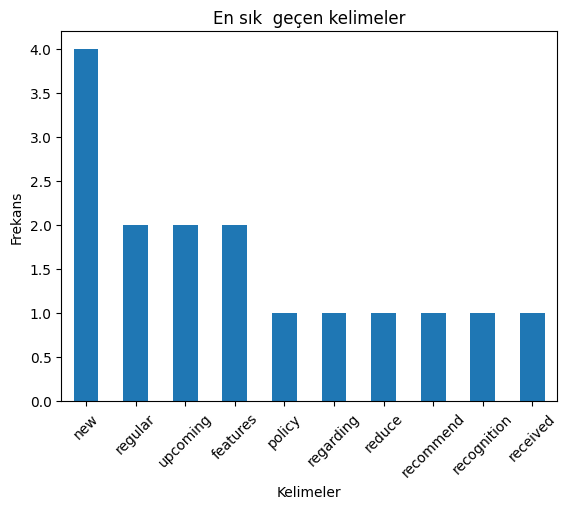

In [ ]:
#görselleştirelim

import matplotlib.pyplot as plt

kelime_frekansları.head(10).plot(kind="bar")
plt.title("En sık  geçen kelimeler")
plt.xlabel("Kelimeler")
plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.show()

#TF-IDF yöntemi

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()
X= vectorizer.fit_transform(cleaned_text)
X

<15x85 sparse matrix of type '<class 'numpy.float64'>'
	with 91 stored elements in Compressed Sparse Row format>

In [ ]:
kelime_kumesi = vectorizer.get_feature_names_out()
kelime_kumesi

array(['actor', 'actors', 'addressed', 'agreement', 'aibased',
       'algorithm', 'announced', 'apple', 'audiences', 'balanced',
       'businesses', 'camera', 'celebrated', 'championship', 'change',
       'checkups', 'climate', 'contract', 'critics', 'developed',
       'diagnosis', 'diet', 'discussed', 'diseases', 'doctors', 'early',
       'essential', 'exercise', 'fans', 'features', 'film', 'game',
       'good', 'government', 'headset', 'health', 'heart', 'helps',
       'includes', 'launch', 'law', 'manchester', 'match', 'model',
       'movie', 'movies', 'nation', 'new', 'next', 'officials',
       'oscarwinning', 'parliament', 'passed', 'planning', 'policy',
       'positive', 'president', 'received', 'recognition', 'recommend',
       'reduce', 'regarding', 'regular', 'researchers', 'retirement',
       'reviews', 'risk', 'serena', 'several', 'signed', 'sleep', 'small',
       'smartphone', 'speech', 'support', 'team', 'tennis', 'three',
       'thrilling', 'united', 'upcomi

In [ ]:
tfidf_df = pd.DataFrame(X.toarray(),columns=kelime_kumesi)
print(tfidf_df.round(4))

     actor  actors  addressed  agreement  aibased  algorithm  announced  \
0   0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.0000   
1   0.0000  0.0000     0.0000     0.0000   0.4001     0.0000     0.0000   
2   0.0000  0.0000     0.4267     0.0000   0.0000     0.0000     0.0000   
3   0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.0000   
4   0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.0000   
5   0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.4472   
6   0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.0000   
7   0.0000  0.0000     0.0000     0.4082   0.0000     0.0000     0.0000   
8   0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.0000   
9   0.0000  0.4261     0.0000     0.0000   0.0000     0.0000     0.0000   
10  0.0000  0.0000     0.0000     0.0000   0.0000     0.0000     0.0000   
11  0.0000  0.0000     0.0000     0.0000   0.0000     0.4267     0.0000   
12  0.0000  0.0000     0.

In [ ]:
toplam_tfidf = tfidf_df.sum(axis=0)

en_yuksek_10 = toplam_tfidf.sort_values(ascending=False).head(10)


en_yuksek_10_df = pd.DataFrame({
    "kelime":en_yuksek_10.index,
    "toplam_tfidf":en_yuksek_10.values
})
print(en_yuksek_10_df)

       kelime  toplam_tfidf
0         new      1.156108
1    upcoming      0.731982
2    features      0.717393
3     regular      0.696115
4       match      0.447214
5  celebrated      0.447214
6        game      0.447214
7        fans      0.447214
8  retirement      0.447214
9  manchester      0.447214


Burda en yüksek tf-idf değeri new kelimesinde

#N-Gram

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
cleaned_text

['manchester united match thrilling game',
 'new smartphone model includes aibased camera features',
 'president addressed nation regarding new policy',
 'regular exercise helps reduce risk heart diseases',
 'movie received positive reviews critics audiences',
 'serena williams announced retirement tennis',
 'apple planning launch vr headset next year',
 'government officials discussed climate change agreement',
 'balanced diet sleep essential good health',
 'upcoming film features several oscarwinning actors',
 'team celebrated championship victory fans',
 'researchers developed new algorithm speech recognition',
 'parliament passed new law support small businesses',
 'doctors recommend regular checkups early diagnosis',
 'actor signed contract three upcoming movies']

In [ ]:
# temizlenmiş metnimizden küçük bir gözlem alalım:

# Listeyi pandas Series'e çevir
series = pd.Series(cleaned_text)

uni_df = series.head(10)
uni_df

,0
0,manchester united match thrilling game
1,new smartphone model includes aibased camera f...
2,president addressed nation regarding new policy
3,regular exercise helps reduce risk heart diseases
4,movie received positive reviews critics audiences
5,serena williams announced retirement tennis
6,apple planning launch vr headset next year
7,government officials discussed climate change ...
8,balanced diet sleep essential good health
9,upcoming film features several oscarwinning ac...


In [ ]:
uni_df.tolist()

['manchester united match thrilling game',
 'new smartphone model includes aibased camera features',
 'president addressed nation regarding new policy',
 'regular exercise helps reduce risk heart diseases',
 'movie received positive reviews critics audiences',
 'serena williams announced retirement tennis',
 'apple planning launch vr headset next year',
 'government officials discussed climate change agreement',
 'balanced diet sleep essential good health',
 'upcoming film features several oscarwinning actors']

In [ ]:
# unigram, bigram, trigram modelleri:
vectorizer_unigram = CountVectorizer(ngram_range=(1,1))
vectorizer_bigram = CountVectorizer(ngram_range=(2,2))
vectorizer_trigram = CountVectorizer(ngram_range=(3,3))

In [ ]:
# unigram:
X_unigram = vectorizer_unigram.fit_transform(uni_df)
unigram_features = vectorizer_unigram.get_feature_names_out()
unigram_features

array(['actors', 'addressed', 'agreement', 'aibased', 'announced',
       'apple', 'audiences', 'balanced', 'camera', 'change', 'climate',
       'critics', 'diet', 'discussed', 'diseases', 'essential',
       'exercise', 'features', 'film', 'game', 'good', 'government',
       'headset', 'health', 'heart', 'helps', 'includes', 'launch',
       'manchester', 'match', 'model', 'movie', 'nation', 'new', 'next',
       'officials', 'oscarwinning', 'planning', 'policy', 'positive',
       'president', 'received', 'reduce', 'regarding', 'regular',
       'retirement', 'reviews', 'risk', 'serena', 'several', 'sleep',
       'smartphone', 'tennis', 'thrilling', 'united', 'upcoming', 'vr',
       'williams', 'year'], dtype=object)

In [ ]:
# DataFrame’e aktar
df = pd.DataFrame(X_unigram.toarray(), columns=unigram_features)
print(df)

   actors  addressed  agreement  aibased  announced  apple  audiences  \
0       0          0          0        0          0      0          0   
1       0          0          0        1          0      0          0   
2       0          1          0        0          0      0          0   
3       0          0          0        0          0      0          0   
4       0          0          0        0          0      0          1   
5       0          0          0        0          1      0          0   
6       0          0          0        0          0      1          0   
7       0          0          1        0          0      0          0   
8       0          0          0        0          0      0          0   
9       1          0          0        0          0      0          0   

   balanced  camera  change  ...  several  sleep  smartphone  tennis  \
0         0       0       0  ...        0      0           0       0   
1         0       1       0  ...        0      0    

In [ ]:
# bigram:
X_bigram = vectorizer_bigram.fit_transform(uni_df)
bigram_features = vectorizer_bigram.get_feature_names_out()
bigram_features

array(['addressed nation', 'aibased camera', 'announced retirement',
       'apple planning', 'balanced diet', 'camera features',
       'change agreement', 'climate change', 'critics audiences',
       'diet sleep', 'discussed climate', 'essential good',
       'exercise helps', 'features several', 'film features',
       'good health', 'government officials', 'headset next',
       'heart diseases', 'helps reduce', 'includes aibased', 'launch vr',
       'manchester united', 'match thrilling', 'model includes',
       'movie received', 'nation regarding', 'new policy',
       'new smartphone', 'next year', 'officials discussed',
       'oscarwinning actors', 'planning launch', 'positive reviews',
       'president addressed', 'received positive', 'reduce risk',
       'regarding new', 'regular exercise', 'retirement tennis',
       'reviews critics', 'risk heart', 'serena williams',
       'several oscarwinning', 'sleep essential', 'smartphone model',
       'thrilling game', 'united

In [ ]:
# DataFrame’e aktar
df = pd.DataFrame(X_bigram.toarray(), columns=bigram_features)
print(df)

   addressed nation  aibased camera  announced retirement  apple planning  \
0                 0               0                     0               0   
1                 0               1                     0               0   
2                 1               0                     0               0   
3                 0               0                     0               0   
4                 0               0                     0               0   
5                 0               0                     1               0   
6                 0               0                     0               1   
7                 0               0                     0               0   
8                 0               0                     0               0   
9                 0               0                     0               0   

   balanced diet  camera features  change agreement  climate change  \
0              0                0                 0               0   
1         

In [ ]:
# trigram:
X_trigram = vectorizer_trigram.fit_transform(uni_df)
trigram_features = vectorizer_trigram.get_feature_names_out()
trigram_features

array(['addressed nation regarding', 'aibased camera features',
       'announced retirement tennis', 'apple planning launch',
       'balanced diet sleep', 'climate change agreement',
       'diet sleep essential', 'discussed climate change',
       'essential good health', 'exercise helps reduce',
       'features several oscarwinning', 'film features several',
       'government officials discussed', 'headset next year',
       'helps reduce risk', 'includes aibased camera',
       'launch vr headset', 'manchester united match',
       'match thrilling game', 'model includes aibased',
       'movie received positive', 'nation regarding new',
       'new smartphone model', 'officials discussed climate',
       'planning launch vr', 'positive reviews critics',
       'president addressed nation', 'received positive reviews',
       'reduce risk heart', 'regarding new policy',
       'regular exercise helps', 'reviews critics audiences',
       'risk heart diseases', 'serena williams a

In [ ]:
# DataFrame’e aktar
df = pd.DataFrame(X_trigram.toarray(), columns=trigram_features)
print(df)

   addressed nation regarding  aibased camera features  \
0                           0                        0   
1                           0                        1   
2                           1                        0   
3                           0                        0   
4                           0                        0   
5                           0                        0   
6                           0                        0   
7                           0                        0   
8                           0                        0   
9                           0                        0   

   announced retirement tennis  apple planning launch  balanced diet sleep  \
0                            0                      0                    0   
1                            0                      0                    0   
2                            0                      0                    0   
3                            0                   

In [ ]:
!pip install gensim
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [ ]:
from sklearn.manifold import TSNE


In [ ]:
cleaned_text

['manchester united match thrilling game',
 'new smartphone model includes aibased camera features',
 'president addressed nation regarding new policy',
 'regular exercise helps reduce risk heart diseases',
 'movie received positive reviews critics audiences',
 'serena williams announced retirement tennis',
 'apple planning launch vr headset next year',
 'government officials discussed climate change agreement',
 'balanced diet sleep essential good health',
 'upcoming film features several oscarwinning actors',
 'team celebrated championship victory fans',
 'researchers developed new algorithm speech recognition',
 'parliament passed new law support small businesses',
 'doctors recommend regular checkups early diagnosis',
 'actor signed contract three upcoming movies']

In [ ]:
cleaned_cumle = [simple_preprocess(sentence)for sentence in cleaned_text]
cleaned_cumle

[['manchester', 'united', 'match', 'thrilling', 'game'],
 ['new', 'smartphone', 'model', 'includes', 'aibased', 'camera', 'features'],
 ['president', 'addressed', 'nation', 'regarding', 'new', 'policy'],
 ['regular', 'exercise', 'helps', 'reduce', 'risk', 'heart', 'diseases'],
 ['movie', 'received', 'positive', 'reviews', 'critics', 'audiences'],
 ['serena', 'williams', 'announced', 'retirement', 'tennis'],
 ['apple', 'planning', 'launch', 'vr', 'headset', 'next', 'year'],
 ['government', 'officials', 'discussed', 'climate', 'change', 'agreement'],
 ['balanced', 'diet', 'sleep', 'essential', 'good', 'health'],
 ['upcoming', 'film', 'features', 'several', 'oscarwinning', 'actors'],
 ['team', 'celebrated', 'championship', 'victory', 'fans'],
 ['researchers', 'developed', 'new', 'algorithm', 'speech', 'recognition'],
 ['parliament', 'passed', 'new', 'law', 'support', 'small', 'businesses'],
 ['doctors', 'recommend', 'regular', 'checkups', 'early', 'diagnosis'],
 ['actor', 'signed', 'contr

In [ ]:
print(cleaned_cumle[:10])

[['manchester', 'united', 'match', 'thrilling', 'game'], ['new', 'smartphone', 'model', 'includes', 'aibased', 'camera', 'features'], ['president', 'addressed', 'nation', 'regarding', 'new', 'policy'], ['regular', 'exercise', 'helps', 'reduce', 'risk', 'heart', 'diseases'], ['movie', 'received', 'positive', 'reviews', 'critics', 'audiences'], ['serena', 'williams', 'announced', 'retirement', 'tennis'], ['apple', 'planning', 'launch', 'vr', 'headset', 'next', 'year'], ['government', 'officials', 'discussed', 'climate', 'change', 'agreement'], ['balanced', 'diet', 'sleep', 'essential', 'good', 'health'], ['upcoming', 'film', 'features', 'several', 'oscarwinning', 'actors']]


In [ ]:
from gensim.models import Word2Vec

model = Word2Vec(
    vector_size=100,
    window=5,
    min_count=1
)

model.build_vocab(cleaned_cumle)
model.train(cleaned_cumle, total_examples=len(cleaned_cumle), epochs=10)


(344, 910)

In [ ]:
model.wv['tennis']

array([ 1.2904672e-03, -9.8124249e-03,  4.5953579e-03, -5.4072635e-04,
        6.3300240e-03,  1.7603530e-03, -3.1276005e-03,  7.7785836e-03,
        1.5564577e-03,  4.3347751e-05, -4.6192869e-03, -8.4765228e-03,
       -7.7747032e-03,  8.6776428e-03, -8.9267651e-03,  9.0268683e-03,
       -9.2749894e-03, -2.7934447e-04, -1.8970239e-03, -8.9471163e-03,
        8.6465618e-03,  6.7876214e-03,  3.0227352e-03,  4.8321909e-03,
        1.1999878e-04,  9.4448999e-03,  7.0037548e-03, -9.8406514e-03,
       -4.4443910e-03, -1.2956011e-03,  3.0437151e-03, -4.3206336e-03,
        1.4567346e-03, -7.8694085e-03,  2.7761278e-03,  4.7052610e-03,
        4.9572927e-03, -3.1940376e-03, -8.4445383e-03, -9.2153866e-03,
       -7.2800583e-04, -7.3284623e-03, -6.8183658e-03,  6.1179502e-03,
        7.1754609e-03,  2.1088801e-03, -7.9138186e-03, -5.7019466e-03,
        8.0718054e-03,  3.9298465e-03, -5.2265115e-03, -7.3968605e-03,
        7.7323307e-04,  3.4739764e-03,  2.0713774e-03,  3.0965293e-03,
      

In [ ]:
model.wv.most_similar('tennis', topn=10)

[('businesses', 0.2329985350370407),
 ('new', 0.21970023214817047),
 ('several', 0.19686926901340485),
 ('celebrated', 0.18780308961868286),
 ('actor', 0.18148066103458405),
 ('diagnosis', 0.18090708553791046),
 ('positive', 0.17545458674430847),
 ('received', 0.1647142469882965),
 ('small', 0.16282932460308075),
 ('three', 0.14449363946914673)]

In [ ]:
# Analojik sorgu:
result = model.wv.most_similar(positive=['reviews', 'regular'], negative=['positive'], topn=1)

print(result)

[('climate', 0.24960720539093018)]


In [ ]:
def closestwords_tsneplot(model, word):
    word_vectors = np.empty((0,100)) # kelime vektör uzunluğu 100 olduğu için 100 verdik
    word_labels = [word]

    close_words = model.wv.most_similar(word)

    word_vectors = np.append(word_vectors, np.array([model.wv[word]]), axis=0)
    # düzleştirme yapmasın diye axis e 0 verdik

    for w, _ in close_words:
        word_labels.append(w)
        word_vectors = np.append(word_vectors, np.array([model.wv[w]]), axis=0)

    # t-SNE ile boyut azaltma
    tsne = TSNE(random_state=0, perplexity=min(30, len(word_vectors) - 1)) # Perplexity değerini(Kaç komşuya dikkat edeceği) veri sayısına göre ayarlar
    Y = tsne.fit_transform(word_vectors)

    x_coords = Y[:, 0]
    y_coords = Y[:, 1]

    plt.scatter(x_coords, y_coords)

    for label, x, y in zip(word_labels, x_coords, y_coords):
        plt.annotate(label, xy=(x, y), xytext=(5, -2), textcoords='offset points')

    plt.show()

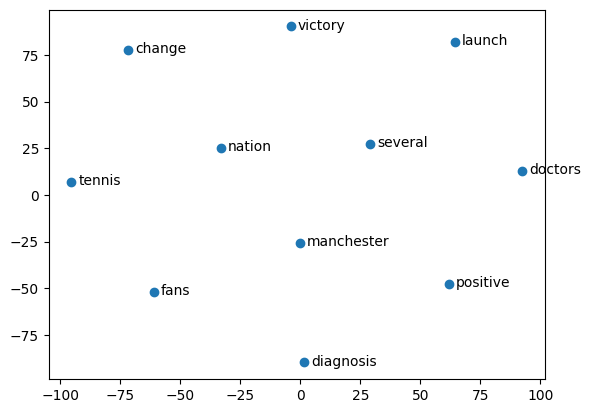

In [ ]:
closestwords_tsneplot(model,'positive')

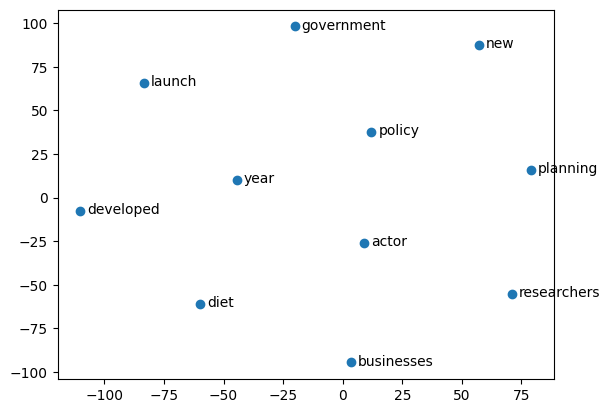

In [ ]:
closestwords_tsneplot(model,'year')